## Validating Your Designs

In the [first tutorial](Tutorial_1_-_Design_of_Protein_Binding_Sites.ipynb) we used Ledidi with a BPNet model to design edits that increase GATA2 binding at the SMYD3 promoter, and pruned the result down to a compact set of edits. That tutorial ends once the edits look good on the model's own global measures. But a model used for design can be *exploited*: gradient-based design can produce sequences that score well on the oracle yet are not biologically meaningful. Before trusting a design you should check it from a few independent angles.

This tutorial collects those checks. We will (1) inspect the edits with attributions to confirm they build the motif we expect, (2) count motif hits with FIMO to confirm the right binding sites were created, and (3) round-trip the designs through entirely separate models (Enformer, an ATAC BPNet) to confirm the effect generalizes beyond the oracle used to design it.

The notebook re-runs the design from Tutorial 1 in a compact recap so it stands on its own; if you have just finished Tutorial 1 the recap will be familiar. As with the other tutorials, the models used here are available at https://zenodo.org/records/14604495.

### Recap: designing and pruning the edits

We load the GATA2 BPNet model (wrapped so it takes only sequence and returns a single count), one-hot encode the SMYD3 promoter region, and confirm GATA2 is not already predicted to bind there.

In [1]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':16:8' # Ignore this for now. Only necessary for reproducibility.

import torch

model = torch.load("../../../../models/bpnet/GATA2.torch", weights_only=False)

In [2]:
from bpnetlite.bpnet import ControlWrapper
from bpnetlite.bpnet import CountWrapper

model = CountWrapper(ControlWrapper(model))

In [3]:
import pyfaidx
from tangermeme.utils import one_hot_encode

chrom, mid = "chr1", 246_507_312

X = pyfaidx.Fasta("../../../../common/hg38.fa")[chrom][mid-1057:mid+1057].seq.upper()
X = one_hot_encode(X).unsqueeze(0).float().cuda()

In [4]:
from tangermeme.predict import predict

y = predict(model, X)
y

tensor([[0.4569]])

A low predicted log count, so there is room to design GATA2 binding in. We set the target to four log-counts above the original prediction, sample a batch of 50 designed sequences, and greedily prune each one down to a compact set of edits -- exactly as in Tutorial 1.

In [5]:
y_bar = y + 4
y_bar

tensor([[4.4569]])

In [6]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('whitegrid')

import pandas
import logomaker

In [7]:
from ledidi import ledidi

torch.manual_seed(0)

X_bar = ledidi(model, X, y_bar, n_samples=50, verbose=True)
y_hat = predict(model, X_bar).numpy(force=True)

iter=I	input_loss=0.0	output_loss=16.0	total_loss=16.0	time=0.0


iter=100	input_loss=31.06	output_loss=0.04793	total_loss=3.154	time=0.6452


iter=200	input_loss=32.75	output_loss=0.07178	total_loss=3.347	time=0.2589


iter=300	input_loss=28.19	output_loss=0.1447	total_loss=2.963	time=0.2593


iter=400	input_loss=22.88	output_loss=0.09238	total_loss=2.38	time=0.261


iter=500	input_loss=22.94	output_loss=0.05315	total_loss=2.347	time=0.259


iter=600	input_loss=22.0	output_loss=0.06426	total_loss=2.264	time=0.2583


iter=700	input_loss=21.06	output_loss=0.09381	total_loss= 2.2	time=0.2584
iter=F	input_loss=16.62	output_loss=0.07087	total_loss=1.733	time=2.242


In [8]:
from tqdm import tqdm
from ledidi.pruning import greedy_pruning

X_bar_p = torch.cat([greedy_pruning(model, X, xb[None], threshold=0.25, verbose=False) for xb in tqdm(X_bar)])

  0%|                                                                                                                                                                                                                                         | 0/50 [00:00<?, ?it/s]

  8%|██████████████████                                                                                                                                                                                                               | 4/50 [00:00<00:01, 29.40it/s]

 14%|███████████████████████████████▌                                                                                                                                                                                                 | 7/50 [00:00<00:01, 24.47it/s]

 20%|████████████████████████████████████████████▊                                                                                                                                                                                   | 10/50 [00:00<00:01, 25.44it/s]

 26%|██████████████████████████████████████████████████████████▏                                                                                                                                                                     | 13/50 [00:00<00:01, 25.00it/s]

...

 76%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                                     | 38/50 [00:01<00:00, 20.71it/s]

 84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                   | 42/50 [00:01<00:00, 23.39it/s]

 90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                      | 45/50 [00:01<00:00, 23.22it/s]

 96%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████         | 48/50 [00:02<00:00, 22.39it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:02<00:00, 22.59it/s]

With `X_bar` (the designed sequences) and `X_bar_p` (their pruned versions) in hand, we can start validating the edits.

### Inspecting Edits using Attributions

So far we have designed edits, shown that they seem to make sense globally, and seen how we can prune them to achieve more compact sets that still seem to perform well on global measures. However, we have not yet inspected these edits and the pruning results to see whether they make biological sense.

A simple way to inspect these sequences is to use an attribution algorithm like DeepLIFT/SHAP, which will highlight the nucleotides and motifs that drive model predictions. We can calculate attributions for the original unedited sequence, the set of edits that were originally proposed, and the pruned set of edits.

In [9]:
from tangermeme.deep_lift_shap import deep_lift_shap

X_attr = deep_lift_shap(model, X, verbose=True, random_state=0).numpy(force=True)
X_attr2 = deep_lift_shap(model, X_bar, verbose=True, random_state=0).numpy(force=True)
X_attr3 = deep_lift_shap(model, X_bar_p, verbose=True, random_state=0).numpy(force=True)

  0%|                                                                                                                                                                                                                                         | 0/20 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 61.78it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 61.15it/s]

  0%|                                                                                                                                                                                                                                       | 0/1000 [00:00<?, ?it/s]

  3%|███████                                                                                                                                                                                                                       | 32/1000 [00:00<00:10, 88.89it/s]

...

 48%|█████████████████████████████████████████████████████████████████████████████████████████████████████████                                                                                                                  | 480/1000 [00:00<00:00, 1348.01it/s]

 64%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                                                              | 640/1000 [00:00<00:00, 1402.35it/s]

 80%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                           | 800/1000 [00:00<00:00, 1435.77it/s]

 96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏        | 960/1000 [00:00<00:00, 1457.45it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1434.02it/s]

Now, we can take a look at these attributions, highlighting the sets of edits that are made with respect to the original sequence.

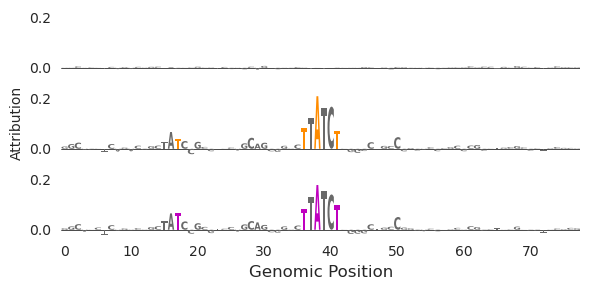

In [10]:
from ledidi.plot import plot_edits

mid = X_attr2[2].sum(axis=0).argmax()
w = 40
start, end = mid - w + 2, mid + w

xa0 = torch.from_numpy(X_attr[0:1, :, start:end])
xa1 = torch.from_numpy(X_attr2[4:5, :, start:end])
xa2 = torch.from_numpy(X_attr3[4:5, :, start:end])

axs = plot_edits(xa0, [xa1, xa2], colors=['k', 'darkorange', 'm'], figsize=(6, 3))
axs[1].set_ylabel("Attribution")
axs[-1].set_xlabel("Genomic Position")
plt.tight_layout()
plt.show()

There are a few things to note here. First, the original sequence (top row) has no high-attribution characters here, suggesting that before edits there is no GATA binding. Second, it looks like the main span of high attribution characters after edits (middle row) is a GATAA motif (but reverse-complemented, so TTATC -> GATAA). This makes sense because we are trying to design GATA2 binding sites. Third, it looks like the pruning (bottom row) got rid of two of the low-attribution characters between the two GATA motifs. Fourth, it looks like a second weak GATA site has been added in to the left of the main one. Interestingly, these edits do not create a high-affinity TF binding site because doing so would likely induce binding stronger than the desired level. Relatedly, because GATA motifs are synergistic, inducing a second weak GATA site near the initial one may yield stronger binding than having two equally-strong sites separated from each other.

Finally, it is somewhat remarkable that this was able to be done in so few edits. Rather than simply implanting the GATA2 motif somewhere in the sequence and calling it a day, Ledidi found a region that was almost a GATA2 motif and added the final characters. This speaks to the precision that Ledidi is able to operate at, where the input loss forces Ledidi to find the best site to turn into a binding site in addition to the right edits that need to be made. Put another way, Ledidi makes the length of the motif be the maximum number of edits needed to unlock the power of implanting that motif and frequently uses far fewer than that number. Sometimes you may need multiple motif copies, in which case the total edits is longer than one motif instance, but the number of edits will be less than the multiplication of the number of motif copies and the length of the motif.

Next, let's take a look at the pruning. We can cross-reference the pruning and the attributions to see which edits are kept.

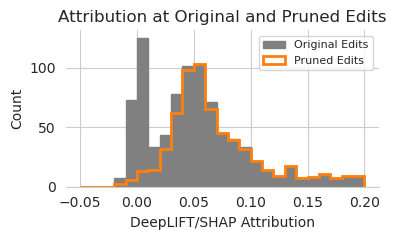

In [11]:
orig_edits = (torch.abs(X_bar - X).sum(dim=-2) != 0).numpy(force=True).flatten()
pruned_edits = (torch.abs(X_bar_p - X).sum(dim=-2) != 0).numpy(force=True).flatten()

orig_edits_attr = X_attr2.sum(axis=1).flatten()[orig_edits]
pruned_edits_attr = X_attr2.sum(axis=1).flatten()[pruned_edits]

plt.figure(figsize=(4, 2.5))
plt.hist(orig_edits_attr, bins=numpy.arange(-0.05, 0.21, 0.01), facecolor='0.5', edgecolor='0.5', label="Original Edits")
plt.hist(pruned_edits_attr, bins=numpy.arange(-0.05, 0.21, 0.01), histtype='step', label="Pruned Edits", linewidth=2)

plt.legend(fontsize=8)
plt.title("Attribution at Original and Pruned Edits")
plt.xlabel("DeepLIFT/SHAP Attribution")
plt.ylabel("Count")
plt.tight_layout()
seaborn.despine(left=True)
plt.show()

It looks like, as one might expect, that the edits with high attribution are the ones kept by the pruning algorithm and the ones with low attribution are generally the one discarded. This is not a perfect overlap, with some of the discarded edits having higher attribution than some of the kept ones, but the trend is pretty clear. Potentially, one could use attributions as a fast approximation for the edits to keep or to prioritize within the pruning algorithm which ones should not even be checked because they have such high attribution.

### Inspecting Edits using Motif Hits

Intuitively, we would expect that at least some of the edits proposed by Ledidi would match known binding motifs for the proteins whose binding we are trying to increase. Of course, these known motifs are not perfect and may be subject to more complicated cis-regulatory rules in specific cellular contexts, but if there are no increases in hits for a known motif than we might be suspicious that the edits might have caused some weird out-of-distribution behavior in the model.

We can check whether the edits create more motif binding sites using FIMO, which scans a PWM against a sequence and then converts this convolution score (the dot product between the PWM and the one-hot encoded sequence) into a p-value that a threshold can be applied against.

First, we load up the JASPAR database. Because it is so large and redundant, for the purpose of this demonstration we just choose a few known proteins -- GATA because we are expecting hits for that, and several others to use as "decoys" who should not have increased motif counts -- and scan those using FIMO.

In [12]:
from tangermeme.io import read_meme
from memelite import fimo
from tangermeme.plot import plot_pwm

motifs = read_meme("../../../../common/JASPAR2024_CORE_non-redundant_pfms_meme.txt")
motif_names = numpy.array(list(motifs.keys()))

motif_subnames = 'GATA', 'CTCF', 'E2F3', 'MAX', 'KLF', 'POU5F1'
motif_subset = [[name for name in motif_names if name_subset in name][0] for name_subset in motif_subnames]

motifs = {name: motifs[name] for name in motif_subset}
motif_names = numpy.array(list(motifs.keys()))
motif_pwms = list(motifs.values())

Now, we can scan the sequences before and after incorporating the edits and count the number of motif instances for each of these motifs. 

In [13]:
hits_before = fimo(motifs, X.cpu(), return_counts=True, threshold=0.001)
hits_after = fimo(motifs, X_bar_p.cpu(), return_counts=True, threshold=0.001) / len(X_bar_p)

hits_diff = hits_after - hits_before
hits_idxs = hits_diff.argsort()

And we can visualize this difference...

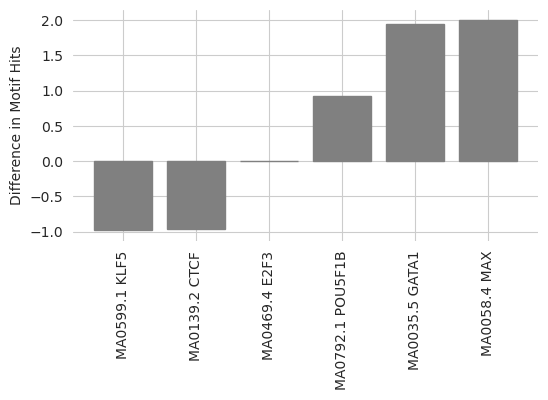

In [14]:
plt.figure(figsize=(6, 3))
plt.bar(range(6), hits_diff[hits_idxs], facecolor='0.5', edgecolor='0.5')
plt.ylabel("Difference in Motif Hits") 

plt.xticks(range(6), motif_names[hits_idxs], rotation=90)
seaborn.despine(bottom=True, left=True)
plt.show()

Looks like there is a big increase in the number of GATA binding sites, and a decrease in the number of other sorts of binding sites. This makes sense, as Ledidi is potentially converting other binding sites into GATA2 sites because this design task is not concerned with preserving these other forms of activity.

### Confirming with Other Models

Finally, we can confirm these edits are generalizable by seeing whether other models make predictions consistent with our editing objective. First, we can see whether Enformer predicts higher GATA2 binding after including the edits than with the original sequence.

In [15]:
import os
os.environ['POLARS_ALLOW_FORKING_THREAD'] = '1'

from enformer_pytorch import from_pretrained

class EnformerWrapper(torch.nn.Module):
    def __init__(self, model, target):
        super(EnformerWrapper, self).__init__()
        self.model = model
        self.target = target
    
    def forward(self, X):
        y = self.model(X[:, :, 33:-33].permute(0, 2, 1))['human']
        return torch.log(y.sum(dim=1)[:, self.target:self.target+1] + 1)
    
enformer_base = from_pretrained('EleutherAI/enformer-official-rough', target_length=16, use_tf_gamma=False)
enformer = EnformerWrapper(enformer_base, 1392)

print("Initial Predictions: ", predict(enformer, X).item())
print("Edited Predictions: ", predict(enformer, X_bar).mean().item())
print("Pruned Predictions: ", predict(enformer, X_bar_p).mean().item())

I0000 00:00:1782190615.605723 3810387 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782190615.637077 3810387 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782190616.524941 3810387 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782190616.525538 3810387 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Initial Predictions:  3.846402645111084


Edited Predictions:  5.141958236694336
Pruned Predictions:  4.950222015380859


Looks like the edits that are designed using a BPNet model increase predictions from an Enformer model on a matched output! This provides another thread of evidence that the edits created by Ledidi are generalizable, because they induce the expected response in a model trained in a totally different setting by other people. Further, when the edits are pruned, the predictons from Enformer go down but only by a little bit. This suggests that the pruning approach is also finding edits that do not really matter too much, even according to an external model. Note that we would not necessarily expect the baseline value from Enformer to be the same as BPNet, especially because our wrapper is taking the sum of predictions across Enformer's target length. 

When proteins bind to DNA they almost always increase chromatin accessibility. Accordingly, a more indirect way to evaluate these edits is to see whether they also induce an increase in predicted chromatin accessibility. We can do this using a few different models, as chromatin accessibility is generally more broadly modeled.

First, we can use Enformer again but with the DNase head instead of the TF ChIP-seq head.

In [16]:
enformer = EnformerWrapper(enformer_base, 121)

print("Initial Predictions: ", predict(enformer, X).item())
print("Edited Predictions: ", predict(enformer, X_bar).mean().item())
print("Pruned Predictions: ", predict(enformer, X_bar_p).mean().item())

Initial Predictions:  3.1928839683532715
Edited Predictions:  3.8485100269317627


Pruned Predictions:  3.793825626373291


Great, looks like we are seeing an increase -- albeit somewhat small -- in accessibility here too.

Next, to use a model that is more similar in output, architecture, and training scheme, we can use a BPNet model that is trained to predict ATAC-seq reads. This is not exactly ChromBPNet because it does not contain the bias model, but that component is less necessary for predicting read counts as opposed to the base-pair resolution profiles.  

In [17]:
bpnet_atac = torch.load("../../../../models/bpnet/ATAC.torch", weights_only=False)
bpnet_atac = CountWrapper(ControlWrapper(bpnet_atac))

print("Initial Predictions: ", predict(bpnet_atac, X).item())
print("Edited Predictions: ", predict(bpnet_atac, X_bar).mean().item())
print("Pruned Predictions: ", predict(bpnet_atac, X_bar_p).mean().item())

Initial Predictions:  3.8743932247161865


Edited Predictions:  4.1382060050964355
Pruned Predictions:  4.138250350952148


Looks like we see a similar result here too, with a small but noticable increase in accessibility. Both Enformer and this model seem to suggest that the region is already somewhat accessible and so the addition of GATA binding does not fundamentally change its openness.

### Conclusions

Taken together, these checks give independent evidence that the designed edits do what we intended and are not an artifact of exploiting the oracle: the attributions show a GATA motif was built where the edits landed, FIMO confirms an increase specifically in GATA hits (and not in decoy motifs), and three separate models -- Enformer's GATA2 head, Enformer's DNase head, and an ATAC BPNet -- all move in the expected direction on the designed sequences. Validating designs like this, ideally with at least one model trained independently of your oracle, is the most important habit to build when using gradient-based sequence design. The remaining tutorials return to *designing* edits under richer constraints and objectives.